In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Does the BT weight scale grow with model size for a real reason?

Open since the meetings of **2026-06-10** and **2026-06-18**:

> רואים מגמה בסקלה של המשקולות, אנחנו יושבים על המתמטיקה בשביל לראות אם זה ארטיפקט אופטימיזציה או סיגנל אמיתי

*We see a trend in the scale of the weights — is it an optimization artifact or real signal?*

This notebook answers it. Five conjectures were tested in parallel; each section states the
conjecture, the test, and the verdict.

---

## What `score` is (needed to read anything below)

`score_x = logP(token_x | prompt) − logP(token_x | base_context)` — a PMI-normalized logprob
of the answer token (`"1"` or `"2"`). So the quantity we regress on is

```
margin = score_a − score_b
       = [logP(1|prompt) − logP(2|prompt)] − [logP(1|base) − logP(2|base)]
```

The base term is a **per-template constant**, so PMI only shifts the margin — it is absorbed
into the intercept γ. That is why the log records "PMI is a no-op". The margin is a genuine
log-odds.

## The model

OLS on the margin, dummy-coded features differenced (A − B), plus an intercept for positional
bias γ. Because `drop_first=True` picks the reference level by **string sort** (ram's reference
is `16GB`, brand's is `ASUS`), single coefficients are contrasts against a moving reference.
Everything below therefore compares **spreads** (max − min, including the dropped level at 0),
which are gauge-invariant.

In [2]:
import json, glob, os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

MODELS = [("qwen", "0.5"), ("qwen", "7"), ("qwen", "32"), ("qwen", "72"),
          ("gemma", "1"),  ("gemma", "4"), ("gemma", "12"), ("gemma", "27")]


def load_runs(constraints_id=None):
    """Every laptops_robustness run as (config, dataframe). None = all constraints."""
    out = []
    for cfg_path in sorted(glob.glob("data/laptops_robustness*/*/config.json")):
        cfg = json.load(open(cfg_path))
        if constraints_id is not None and cfg.get("constraints_id", "none") != constraints_id:
            continue
        df = pd.read_csv(os.path.join(os.path.dirname(cfg_path), "scores.csv"))
        out.append((cfg, df))
    return out


def fit_bt(df):
    """OLS Bradley-Terry with positional bias. Returns (weights dict, gamma, results)."""
    Y = (df.score_a - df.score_b).values
    cols_a = [c for c in df.columns if c.startswith("a_")]
    cols_b = [c.replace("a_", "b_") for c in cols_a]
    base = [c[2:] for c in cols_a]
    A = df[cols_a].rename(columns=dict(zip(cols_a, base)))
    B = df[cols_b].rename(columns=dict(zip(cols_b, base)))
    D = pd.get_dummies(pd.concat([A, B]), drop_first=True, dtype=float)
    X = sm.add_constant(D.iloc[:len(df)].values - D.iloc[len(df):].values)
    res = sm.OLS(Y, X).fit()
    return dict(zip(D.columns, res.params[1:])), res.params[0], res


def spread(weights, prefix):
    """Gauge-invariant size of one feature block: max - min, with the dropped level at 0."""
    vals = [v for k, v in weights.items() if k.startswith(prefix)] + [0.0]
    return max(vals) - min(vals)

---

## 1. The phenomenon

Unconstrained runs only (`constraints_id == "none"`), one row per model.

In [3]:
rows = []
for cfg, df in load_runs("none"):
    w, gamma, res = fit_bt(df)
    rows.append(dict(
        family=cfg["model_family"], size=float(cfg["model_size"]),
        brand=spread(w, "brand"), screen=spread(w, "screen"), ram=spread(w, "ram"),
        gamma=gamma, r2=res.rsquared, resid_sd=np.std(res.resid),
        margin_sd=(df.score_a - df.score_b).std(),
    ))
base_table = pd.DataFrame(rows).sort_values(["family", "size"]).reset_index(drop=True)
base_table["total_spread"] = base_table.brand + base_table.screen + base_table.ram
base_table["spread_over_noise"] = base_table.total_spread / base_table.resid_sd
base_table.round(3)

,family,size,brand,screen,ram,gamma,r2,resid_sd,margin_sd,total_spread,spread_over_noise
0,gemma,1.0,2.759,2.477,15.645,-6.941,0.654,6.829,11.608,20.881,3.058
1,gemma,4.0,3.406,3.945,29.992,-8.514,0.832,7.996,19.489,37.343,4.670
2,gemma,12.0,2.469,4.289,25.922,-10.521,0.847,6.534,16.723,32.680,5.002
3,gemma,27.0,4.879,6.781,30.926,-7.834,0.794,9.495,20.923,42.586,4.485
4,qwen,0.5,0.125,0.052,0.157,-0.223,0.085,0.417,0.436,0.334,0.800
5,qwen,7.0,0.858,3.900,26.526,-9.049,0.864,6.212,16.857,31.284,5.036
6,qwen,32.0,3.815,4.653,35.194,-6.984,0.853,8.648,22.578,43.663,5.049
7,qwen,72.0,2.845,4.256,25.392,-9.437,0.857,6.179,16.344,32.493,5.259


### Four things to notice

1. **The trend is not monotonic.** qwen goes 0.33 → 31.3 → 43.7 → 32.5, so **72B sits below
   32B**. gemma goes 20.9 → 37.3 → 32.7 → 42.6. The one enormous step is 0.5B → 7B.
2. **`total_spread / resid_sd` is nearly constant** at 4.5–5.3 for every model that has signal,
   while `total_spread` itself ranges 31 → 44. Weights and noise inflate together.
3. **RAM dominates** (25–35) over screen (2.5–6.8) and brand (0.8–4.9) — consistent with the
   established lexicographic finding, where RAM acts as a veto rather than a weight.
4. **γ is huge** (−7 to −10.5), the same order as the weights themselves.

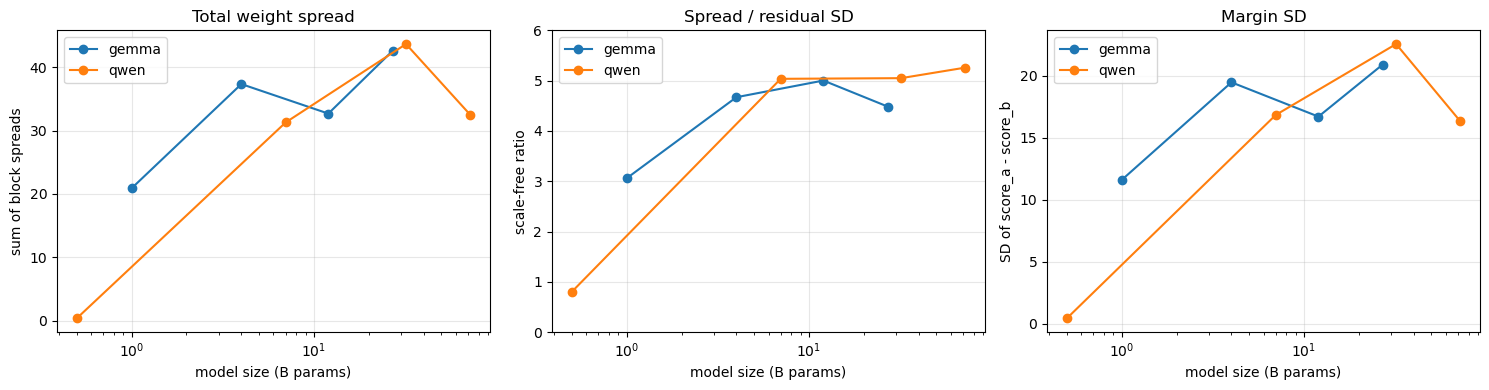

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for fam, g in base_table.groupby("family"):
    g = g.sort_values("size")
    axes[0].plot(g["size"], g.total_spread, "o-", label=fam)
    axes[1].plot(g["size"], g.spread_over_noise, "o-", label=fam)
    axes[2].plot(g["size"], g.margin_sd, "o-", label=fam)
for ax, title, ylab in zip(
        axes,
        ["Total weight spread", "Spread / residual SD", "Margin SD"],
        ["sum of block spreads", "scale-free ratio", "SD of score_a - score_b"]):
    ax.set_xscale("log"); ax.set_xlabel("model size (B params)")
    ax.set_ylabel(ylab); ax.set_title(title); ax.legend(); ax.grid(alpha=.3)
axes[1].set_ylim(0, 6)
plt.tight_layout()

### Saturation

A margin of 16 means p(win) = 0.99999989. These are not meaningful probabilities — the losing
option's logprob has crashed toward a floor.

In [5]:
sat = []
for cfg, df in load_runs("none"):
    s = np.concatenate([df.score_a.values, df.score_b.values])
    m = (df.score_a - df.score_b).abs()
    sat.append(dict(family=cfg["model_family"], size=float(cfg["model_size"]),
                    min_score=s.min(), max_score=s.max(),
                    frac_below_m20=(s < -20).mean(),
                    frac_margin_gt10=(m > 10).mean(),
                    p_win_at_mean_margin=1 / (1 + np.exp(-m.mean()))))
pd.DataFrame(sat).sort_values(["family", "size"]).round(4)

,family,size,min_score,max_score,frac_below_m20,frac_margin_gt10,p_win_at_mean_margin
4,gemma,1.0,-15.8750,10.2500,0.0000,0.4234,1.0000
5,gemma,4.0,-23.6250,10.5000,0.0957,0.7916,1.0000
6,gemma,12.0,-25.0000,9.7500,0.0874,0.6601,1.0000
7,gemma,27.0,-28.5000,5.0000,0.1728,0.9412,1.0000
3,qwen,0.5,-0.4844,0.8906,0.0000,0.0000,0.6055
1,qwen,7.0,-28.9844,6.0703,0.1328,0.7257,1.0000
2,qwen,32.0,-34.4375,3.1816,0.2431,0.8660,1.0000
0,qwen,72.0,-29.8750,5.5000,0.1404,0.6231,1.0000


---

# 2. Five conjectures

| # | conjecture | verdict |
|---|---|---|
| C1 | The scale is set by **saturation** against a logprob floor | *(pending)* |
| C2 | **There is no monotonic trend** — it is one model at the bottom | **supported** |
| C3 | One **global scale factor** inflates everything together | **rejected as stated**, but gives the fix |
| C4 | It is **real signal** — bigger models prefer more strongly | **mostly rejected**: louder, not different |
| C5 | It is a **template-pooling** artifact | **rejected** — but overturns qwen-0.5B |

Each section below states the test and the numbers.

---

## C2 — Is the trend even there? **No.**

### The trend never reaches significance

| subset | n | Spearman | p (exact) | bootstrap 95% CI on ρ |
|---|---|---|---|---|
| all 8 | 8 | 0.67 | 0.083 | [−0.15, 1.00] |
| drop qwen-0.5 | 7 | 0.50 | 0.267 | [−0.43, 1.00] |
| drop qwen-0.5 + gemma-1 | 6 | 0.20 | 0.714 | [−0.80, 1.00] |
| qwen only | 4 | 0.80 | 0.333 | [0.33, 1.00] |
| gemma only | 4 | 0.80 | 0.333 | [0.33, 1.00] |

Among the top 6 models, **6 of 15 size-ordered pairs go the wrong way** — near the 7.5 you get
from coin flips.

> **Design flaw worth remembering:** with 4 sizes per family, the smallest possible two-sided
> Spearman p is **0.083**. A within-family trend can *never* be significant with this design,
> no matter how clean it is. Any future scaling claim needs more sizes, not more rows.

### Leave-one-out: only qwen-0.5B carries the effect

Slope per decade of parameters, all 8 models: **13.81** (p = 0.014).
Drop qwen-0.5B: **7.09** (p = 0.073). Dropping any *other* model moves the slope by less than 4.

### The number that settles it

| set | within-model SD (across the 4 constraints) | between-model SD | ratio |
|---|---|---|---|
| all 8 | 3.40 | 12.59 | 3.70 |
| drop qwen-0.5 | 3.63 | 5.97 | 1.64 |
| **drop qwen-0.5 + gemma-1** | **3.90** | **4.00** | **1.03** |

**Among the top 6 models, changing which model you use moves the weight spread by exactly as
much as changing the constraint sentence inside one model.** "Which model" is no bigger a lever
than "which prompt".

### The non-monotonicity is real, not sampling noise

Cluster bootstrap over the 990 unordered item pairs (the correct unit — 2 orders × 5 templates
share a pair), 400 draws:

| model | total | 95% CI |
|---|---|---|
| qwen-7 | 31.28 | [30.50, 32.64] |
| qwen-72 | 32.49 | [31.75, 33.83] |
| qwen-32 | 43.66 | [42.31, 45.40] |

qwen-72 sitting below qwen-32 is **not** noise — the CIs are 8 points apart and do not touch.

In [6]:
# C2's variance split - the load-bearing number.
def variance_split(t):
    """t: one row per run with columns family, size, total_spread.
    Returns (within-model SD across constraints, between-model SD corrected for it)."""
    t = t.assign(model=t.family + "-" + t["size"].astype(str))
    g = t.groupby("model")["total_spread"]
    within = np.sqrt((g.std(ddof=1) ** 2).mean())
    k = t.groupby("model").size().mean()
    between = np.sqrt(max(g.mean().std(ddof=1) ** 2 - within ** 2 / k, 0))
    return within, between


rows = []
for cfg, df in load_runs():                      # all 4 constraint conditions
    w, gamma, res = fit_bt(df)
    rows.append(dict(family=cfg["model_family"], size=float(cfg["model_size"]),
                     cons=cfg["constraints_id"],
                     total_spread=sum(spread(w, f) for f in ["brand", "screen", "ram"]),
                     margin_sd=(df.score_a - df.score_b).std()))
all_runs = pd.DataFrame(rows)

for label, sub in [
        ("all 8", all_runs),
        ("drop qwen-0.5", all_runs[~((all_runs.family == "qwen") & (all_runs["size"] == 0.5))]),
        ("drop qwen-0.5 + gemma-1", all_runs[~(((all_runs.family == "qwen") & (all_runs["size"] == 0.5))
                                               | ((all_runs.family == "gemma") & (all_runs["size"] == 1)))])]:
    wi, be = variance_split(sub)
    print(f"{label:26s} within={wi:5.2f}  between={be:5.2f}  ratio={be/wi:4.2f}")

all 8                      within= 3.35  between=12.60  ratio=3.76
drop qwen-0.5              within= 3.58  between= 5.96  ratio=1.66
drop qwen-0.5 + gemma-1    within= 3.84  between= 3.94  ratio=1.02


---

## C5 — Template pooling? **Rejected — but it overturns qwen-0.5B.**

The design is perfectly balanced (1980 rows per template, the same 1980 pairs), so template
dummies are **exactly orthogonal** to the differenced feature dummies. Adding template fixed
effects changes every weight by **0.000**, for every model.

*This closes the open log item "template is pooled; make it a random effect and see if the
leakage slopes move." The slopes do not move.*

### What pooling DOES break: the residual SD — and it rewrites qwen-0.5B

| family | size | R² pooled | R² + template FE | ICC |
|---|---|---|---|---|
| gemma | 1 | 0.654 | 0.795 | 0.47 |
| gemma | 4–27 | 0.79–0.85 | unchanged (≤0.005) | ≤0.15 |
| **qwen** | **0.5** | **0.085** | **0.920** | **0.92** |
| qwen | 7–72 | 0.85–0.86 | unchanged (≤0.005) | ≤0.15 |

**qwen-0.5B is not a noise model.** It has a highly reproducible but *tiny* preference. Its
per-template γ is −0.7, +0.3, +0.2, −0.5, −0.4 — a range of 1.0, which is **3× its entire
feature spread of 0.33**. The pooled fit drowned the preference in a per-template positional
constant.

**This contradicts what we had written down as settled** ("qwen-0.5B has no measurable
preference on anything").

### Five templates is enough

The `screen=14-inch` condition was collected twice: 5 templates (9900 rows) and 43 templates
(85140 rows). Subsampling 5 of 43, 400 draws: mean 31.44, **SD 0.99**, and the real 5-template
estimate (31.73) sits at percentile 0.59 — dead centre, no bias. Against a between-model range
of 22.8, an SE of 1.0 is plenty. **Do not collect more templates.**

### Side finding: wording moves what the model obeys

Same model, same items, same `screen=14-inch` contract. Screen spread = contract-following,
ram spread = the model's own preference:

| template | ram | screen | who wins |
|---|---|---|---|
| 35 — *"Which aligns more with your preferences: option 1 or option 2?"* | 12.8 | 15.0 | **contract** |
| 20 — *"Between the two, do you prefer option 1 or 2?"* | 27.0 | 9.0 | **own preference, 3×** |

All 43 templates are paraphrases of *"which do you prefer"* — there is no *"choose one"* or
*"which is better"*. So this set says nothing about instruction strength directly, but it is
early evidence that the planned instruction-strength experiment will find something.

---

## C3 — One global scale factor? **Rejected as stated — but it hands us the fix.**

### Three things break the one-scalar story

**Feature blocks scale by different amounts.** Fitting `w_i = c · w_j` separately per block:

| pair | c_brand | c_screen | c_ram | max/min |
|---|---|---|---|---|
| qwen-7 / qwen-72 | 0.248 | 0.913 | 1.043 | **4.20** |
| qwen-7 / qwen-32 | 0.224 | 0.819 | 0.752 | **3.66** |
| gemma-1 / qwen-7 | 1.920 | 0.623 | 0.588 | **3.26** |
| gemma-4 / qwen-32 | 0.782 | 0.795 | 0.847 | 1.08 (best) |

Over all 21 pairs: median max/min **1.64**. Three block scalars remove a median **31%** of the
one-scalar residual.

**γ does not scale with the weights.** Over the 28 signal runs, r = **+0.14** (p = 0.47).
Pairwise, corr(fitted `c_ij`, `γ_i/γ_j`) = **0.111**. γ is roughly **constant at −8.4 ± 1.9**.
*(The r = +0.77 you get over all 32 runs is fake — qwen-0.5 contributes 4 points where both
quantities are ≈ 0.)*

**Standardized margins do not collapse.** KS between z-scored margin distributions: 0.05–0.23.

### Watch out: RAM is 93–98% of the weight vector

| what is in the vector | median R² of the one-scalar fit |
|---|---|
| full 11-dim | 0.985 |
| RAM block only | **0.999** |
| brand + screen only | **0.833** |

The impressive 0.985 is a RAM artifact. Anything computed on the full weight vector is mostly
measuring RAM.

### The fix: normalize by `margin_SD`, not `resid_SD`

| divide by | rel. between-run variance | CV of total spread |
|---|---|---|
| L2 norm of w | 0.262 | 0.098 |
| **margin_SD** | **0.263** | **0.095** |
| raw (nothing) | 0.291 | 0.205 |
| **resid_SD** | **0.299** | 0.194 |

**`resid_SD` is a worse normalizer than doing nothing.** The "spread/resid_SD ≈ 5" pattern in
section 1 is a coincidence of the 7 unconstrained runs; over all 28 its CV is double
`margin_SD`'s.

| quantity | family × constraint cells rising monotonically with size (of 8) |
|---|---|
| raw total spread | **0 of 8** |
| spread / resid_SD | 4 of 8 |
| **spread / margin_SD** | **6 of 8** |

Under the right normalization a monotone trend appears where the raw scale had none
(qwen: 1.856 → 1.934 → 1.988 instead of 31.3 → 43.7 → 32.5). Both misses are gemma's `ram=8GB`.
Underpowered: ρ = +1 at n = 3 has p ≈ 0.17.

### Follow-up: is the block result just noisy brand estimates?

The "blocks scale differently" verdict rested on the brand block, whose spread is only 0.9–4.9.
Bootstrapped with 400 reps clustered on the **990 unordered item-pairs** (the correct unit),
testing the ratios `c_brand/c_ram` and `c_screen/c_ram` paired inside each rep:

| pair | c_brand / c_ram | c_screen / c_ram | rejects one scalar? |
|---|---|---|---|
| qwen-7 / qwen-72 | 0.24 [0.09, 0.38] | 0.88 [0.82, 0.94] | **yes, both** |
| qwen-7 / qwen-32 | 0.30 [0.14, 0.46] | 1.09 [1.02, 1.17] | **yes, both** |
| gemma-1 / qwen-7 | 3.26 [−0.01, 5.46] | 1.06 [0.96, 1.20] | **no** |

**Verdict holds: 18 of 21 pairs reject one scalar** — and it does *not* rest on brand. The
well-measured **screen** block rejects on its own with tight intervals (gemma-27/qwen-7:
`c_screen/c_ram` = 1.49 [1.41, 1.59]). The 3 pairs that fail all involve qwen-7's unmeasurable
brand vector (spread 0.86, CI [0.53, 1.71]).

Pair-clustering widens the brand CI by a median **2.28×** over a naive row bootstrap —
confirming the log's "naive SEs overstate confidence ~3×".

### Honest downgrade: no single block is monotone

| quantity | cells with ρ = +1.00 (of 8) | mean ρ |
|---|---|---|
| brand / margin_SD | 3/8 | +0.05 |
| screen / margin_SD | 2/8 | +0.38 |
| **ram / margin_SD** | **0/8** | **−0.26** |
| **total / margin_SD** | **6/8** | **+0.88** |

RAM — the dominant block — is the one that is *not* monotone. The total is monotone **as a sum
while none of its three parts is**. So `total_spread / margin_SD` is a good normalized
statistic, but we cannot say "one thing grows with size".

### Where the global-scale idea IS right, narrowly

On the dominant axis, in margin-SD units, the RAM veto is **the same size in every model**
across a 72× range of parameters:

| quantity | mean | CV |
|---|---|---|
| raw ram_spread | 27.09 | 0.226 |
| **ram_spread / margin_SD** | **1.514** | **0.053** |
| screen_spread / margin_SD | 0.242 | 0.178 |
| brand_spread / margin_SD | 0.170 | 0.367 |

For RAM the scale is pure nuisance carrying no preference information (CV drops 4.3×). For
screen and brand it does not fully wash out.

In [7]:
# C3's fix: the scale-free version of the trend.
all_runs["norm_spread"] = all_runs.total_spread / all_runs.margin_sd
print("total_spread / margin_SD\n")
print(all_runs.pivot_table(index=["family", "size"], columns="cons",
                           values="norm_spread").round(3).to_string())

total_spread / margin_SD

cons          none  ram=8GB  ram=8GB+screen=14-inch  screen=14-inch
family size                                                        
gemma  1.0   1.799    1.714                   1.852           1.860
       4.0   1.916    1.781                   1.951           1.933
       12.0  1.954    1.745                   2.202           2.157
       27.0  2.035    1.716                   2.233           2.105
qwen   0.5   0.765    1.700                   1.604           1.155
       7.0   1.856    1.643                   2.086           2.041
       32.0  1.934    1.681                   2.203           2.144
       72.0  1.988    1.859                   2.312           2.194


---

## C4 — Real signal? **Mostly rejected. Bigger models are louder, not different.**

Every measure here is scale-free: multiply a run's margins by any `c > 0` and it does not move.

### The clincher — length vs angle

Split the difference between two models' fitted weight vectors into a **length** part (louder)
and an **angle** part (genuinely different preferences):

| set of pairs | median angle | **max angle** | median length diff | **max length diff** |
|---|---|---|---|---|
| all 28 pairs | 6.3° | 51.0° | 33% | 17500% |
| **21 pairs, working models only** | **5.2°** | **9.1°** | **19%** | **113%** |

**The weight vector never turns more than 9.1°, while its length changes by up to 113%.**
One model's per-pair preference explains 96% of another's, with a slope far from 1.

Rank correlation of the 45 laptops across working models: **Spearman 0.971–0.995.** Where two
models disagree on a winner (2.2–6.4% of pairs), those pairs have mean |margin| only **18%** of
average — disagreement is noise on near-ties, not different taste.

### Every scale-free quality measure is at a ceiling above ~4B

| model | spread | order agree | all-5-template agree | SST violations | 3-cycles /14190 | held-out acc |
|---|---|---|---|---|---|---|
| gemma-1 | 20.9 | 0.646 | 0.916 | 0.018 | 18 | 0.952 |
| gemma-4 | 37.3 | 0.830 | 0.933 | 0.011 | 7 | 0.971 |
| gemma-12 | 32.7 | 0.817 | 0.952 | 0.009 | 12 | 0.974 |
| gemma-27 | 42.6 | 0.916 | **0.985** | **0.000** | 2 | **0.987** |
| qwen-0.5 | 0.33 | **0.006** | **0.529** | **0.158** | **453** | 0.769 |
| qwen-7 | 31.3 | 0.724 | **0.985** | 0.000 | 1 | **0.990** |
| qwen-32 | 43.7 | 0.848 | 0.971 | 0.010 | 45 | 0.973 |
| qwen-72 | 32.5 | 0.808 | 0.980 | 0.003 | 10 | 0.976 |

qwen-7B is the **best** of all 8 on held-out accuracy. 32B and 72B are worse while their
spreads are larger or equal.

### Does the weight scale buy any ordinal quality? No.

Spearman, excluding the broken qwen-0.5:

| quality measure | vs **spread** | vs **log size** |
|---|---|---|
| template-agreement error | **−0.216** | −0.577 |
| held-out error | **−0.036** | −0.464 |
| 3-cycle rate | **+0.143** | +0.107 |

**Size buys a little consistency; the weight spread buys nothing.** And the little that size
buys is almost entirely gemma, which starts below the ceiling — qwen hits the ceiling at 7B
and then does nothing while its spread goes 31 → 44 → 32.

### Lexicographic structure is already complete at 4B

**RAM veto rate is exactly 1.000 for six of the seven working models** — when two laptops
differ in RAM, the higher-RAM one wins 100% of the time regardless of brand or screen. It
cannot increase, so no size trend is possible. Standardized effect size (`d` = spread /
residual SD) is 4.5–5.3 for every working model.

One weak signal in the other direction: RAM's *share* of total spread **falls** with size in
both families above 4B (gemma 0.803 → 0.793 → 0.726; qwen 0.848 → 0.806 → 0.782), with
screen's share rising. Small, but the same direction in both families.

### Spin-off: bigger models let the contract override their own RAM preference

This came out of the normalization work and is **not** about scale. Under `screen=14-inch`,
in margin-SD units:

| | gemma-1 | gemma-4 | gemma-12 | gemma-27 | qwen-7 | qwen-32 | qwen-72 |
|---|---|---|---|---|---|---|---|
| screen / margin_SD | 0.286 | 0.372 | 1.135 | **1.324** | 0.552 | 1.199 | 1.152 |
| ram / margin_SD | 1.366 | 1.472 | 0.963 | **0.713** | 1.403 | 0.870 | 0.984 |

Screen spread = contract-following; ram spread = the model's own preference. **Bigger models
shift weight from their own preference onto the stated contract.** Same pattern under
`ram=8GB+screen=14-inch` (gemma screen 0.272 → 1.026).

This is the scale-free version of the established "contract adherence scales with model size"
finding — and unlike the weight scale, it is a genuine preference result. Not tested properly
here; flagged for its own analysis.

---

## C1 — Saturation? **Right conclusion, wrong mechanism — and it finds the real one.**

### There is no floor

`l_loss` = the loser's raw logprob. If margins were censored, losers would pile up at a minimum.

| model | loser min | % within 0.5 of min | % within 2 of min |
|---|---|---|---|
| qwen-7 | −29.05 | 0.08% | 0.21% |
| qwen-32 | −35.37 | 0.06% | 2.04% |
| gemma-27 | −28.51 | 0.18% | **7.20%** |

Smooth over 30 log units, nothing at the bottom. **What saturates is the *winner*, not the
loser** — `l_win` is exactly 0.0 for 82–98.5% of rows. That costs no information: since
p₁ + p₂ = 1, the loser carries everything and has full dynamic range.

**Tobit confirms there is nothing to correct.** Only 0.02–0.05% of rows sit at a limit, and
tobit total spread equals OLS to 2 decimals for all 7 models.

> A useful warning found on the way: artificially censoring at ±10 and refitting gives tobit
> spreads of 73.8 (truth 31.3), 171.7 (truth 43.7), **689.4** (truth 42.6). Never trust a tobit
> on heavily censored data of this kind.

### The decisive test: the log-odds does not depend on how big the difference is

Position-free log-odds, median over matched pairs:

| swap | qwen-7 | qwen-32 | qwen-72 | gemma-1 | gemma-4 | gemma-12 | gemma-27 |
|---|---|---|---|---|---|---|---|
| ram 4 vs 8 (2×) | 22.53 | 29.13 | 22.77 | 13.52 | 20.05 | 20.30 | 24.27 |
| ram 8 vs 16 (2×) | 21.39 | 27.22 | 20.23 | 12.64 | 20.55 | 19.85 | 22.53 |
| **ram 4 vs 16 (4×)** | **21.70** | **29.04** | **22.49** | **14.07** | **21.73** | **20.80** | **23.75** |

**A four-fold RAM gap gets the same log-odds as a two-fold gap, in every model.** Same for
screen.

Under a cardinal utility, `L(4→16)` should equal `L(4→8) + L(8→16)` — ratio 1. Observed:

| model | qwen-0.5 | qwen-7 | qwen-32 | qwen-72 | gemma-1 | gemma-4 | gemma-12 | gemma-27 |
|---|---|---|---|---|---|---|---|---|
| ram ratio | **0.53** | 0.49 | 0.52 | 0.53 | 0.53 | 0.54 | 0.52 | 0.51 |

Ratio 0.5 for everyone — **including qwen-0.5B, which has zero saturation** (all its log-odds
under 0.6). So this is not squashing against a ceiling. It is a **categorical response**: the
model emits one fixed magnitude `S` whenever "more RAM wins", so direct = S, two-step = 2S,
ratio 0.5.

**This is what kills the strength interpretation.** The dummy fit reports
`ram_4GB = −26.5, ram_8GB = −12.6, ram_16GB = 0`, which makes 4GB look twice as bad as 8GB.
The raw data says 4-vs-8 and 4-vs-16 are equally decided. **The ladder comes from the design —
how often each level wins — not from preference strength.**

### One temperature per model

SVD of the 7 weight vectors: **rank-1 explains 99.64% of the variance.** Pairwise cosine
between unit-normalised weight vectors: 0.987–0.999, across both families. (Independent
agreement with C4's 9.1° maximum angle.)

| model | rank-1 "temperature" | total spread |
|---|---|---|
| gemma-1 | 18.2 | 20.9 |
| qwen-72 | 28.3 | 32.5 |
| gemma-12 | 29.2 | 32.7 |
| qwen-7 | 29.7 | 31.3 |
| gemma-4 | 34.2 | 37.3 |
| gemma-27 | 35.1 | 42.6 |
| qwen-32 | 39.0 | 43.7 |

Not monotonic in size (qwen 29.7 → 39.0 → 28.3).

### Does saturation beat size? **No — I checked, and it is circular**

`frac(|margin| > 10)` and total spread are computed from the *same* margins, so both are
monotone functions of one number. Measuring saturation on **disjoint rows** (the 900 brand-only
rows) and fitting spread on the other 9000:

| sample | log(size) r | saturation on **same** rows | saturation on **disjoint** rows |
|---|---|---|---|
| all 32 runs | 0.79 | 0.961 | 0.485 (p = 0.005) |
| 28, no qwen-0.5 | 0.63 | 0.859 | **0.268 (p = 0.17, n.s.)** |
| 8 unconstrained | 0.81 | 0.989 | 0.588 (p = 0.13, n.s.) |

A within-model check (size fixed, 4 constraints each) gives 4 positive / 3 negative
correlations. **Saturation does not order the models better than size.** The defensible claim
is stronger: *neither* is causal. There is one latent decisiveness scalar `T` per model;
spread ≈ T × shape, and saturation ≈ P(T·shape > 10). Both are `T` in different clothes.

### The two-point margin shape is NOT a ceiling effect

This corrects C3's reading. qwen-0.5B is the anchor: **zero saturation, max |logit| 1.2**, yet
the same flat bimodal shape (kurtosis −1.30 vs −1.55 to −1.86 for the rest). The shape exists
where no ceiling can be reached, so a ceiling cannot be its origin. It is the categorical
response above, present at every scale.

### Two measurement bugs C1 found on the way

**1. γ is currently reported wrong.** The base prompt is `prompt.split('\n')[-1]`, and every
prompt ends with a newline — so the base context is the **empty string**, one constant per run.
The PMI part of the intercept is `−max(score_a) + max(score_b)`, and it must be subtracted:

| model | γ as reported | γ corrected |
|---|---|---|
| qwen-7 | −9.05 | **−3.05** |
| gemma-1 | −6.94 | **+3.31** ← sign flips |

**2. The pooled OLS shrinks small effects 3–5×.** Fitting on design cells where only one
feature differs, versus the joint fit:

| model | brand spread, joint fit | brand spread, brand-only cells | shrink |
|---|---|---|---|
| qwen-7 | 0.86 | 4.81 | **5.6×** |
| qwen-32 | 3.82 | 13.77 | 3.6× |
| gemma-27 | 4.88 | 20.11 | 4.1× |

Wherever RAM differs the answer is pinned regardless of brand, so brand gets no leverage there
and OLS averages it away. **The "RAM dominates everything" gap is partly manufactured by the
pooled fit.** The lexicographic *ordering* survives; the *size* of the gap is overstated.

And a sanity number worth keeping: two laptops identical except the brand name still get
near-certainty. gemma-27, Apple vs HP: log-odds **17.52**, i.e. p = 1 − 2.5e−8.

In [8]:
# C1's decisive test, reproduced here: is the log-odds flat in the size of the gap?
def gap_size_test(df, feature="ram", levels=("4GB", "8GB", "16GB")):
    """Position-free log-odds for each level swap, holding the other features equal."""
    other = [c[2:] for c in df.columns if c.startswith("a_") and c[2:] != feature]
    d = df.assign(m=df.score_a - df.score_b)
    key_a = [f"a_{c}" for c in other]
    key_b = [f"b_{c}" for c in other]
    tied = d[(d[key_a].values == d[key_b].values).all(axis=1)]
    out = {}
    for lo, hi in [(levels[0], levels[1]), (levels[1], levels[2]), (levels[0], levels[2])]:
        f = tied[(tied[f"a_{feature}"] == hi) & (tied[f"b_{feature}"] == lo)]
        r = tied[(tied[f"a_{feature}"] == lo) & (tied[f"b_{feature}"] == hi)]
        out[f"{lo} vs {hi}"] = round((f.m.median() - r.m.median()) / 2, 2)
    return out


for cfg, df in load_runs("none"):
    name = f'{cfg["model_family"]}-{cfg["model_size"]}'
    g = gap_size_test(df)
    direct, two_step = g["4GB vs 16GB"], g["4GB vs 8GB"] + g["8GB vs 16GB"]
    print(f"{name:10s} {g}  ratio direct/2-step = {direct/two_step:.2f}")

qwen-72    {'4GB vs 8GB': np.float64(22.25), '8GB vs 16GB': np.float64(19.75), '4GB vs 16GB': np.float64(22.25)}  ratio direct/2-step = 0.53
qwen-7     {'4GB vs 8GB': np.float64(22.07), '8GB vs 16GB': np.float64(20.85), '4GB vs 16GB': np.float64(21.43)}  ratio direct/2-step = 0.50
qwen-32    {'4GB vs 8GB': np.float64(28.75), '8GB vs 16GB': np.float64(27.12), '4GB vs 16GB': np.float64(29.0)}  ratio direct/2-step = 0.52
qwen-0.5   {'4GB vs 8GB': np.float64(0.25), '8GB vs 16GB': np.float64(0.06), '4GB vs 16GB': np.float64(0.12)}  ratio direct/2-step = 0.39
gemma-1    {'4GB vs 8GB': np.float64(13.69), '8GB vs 16GB': np.float64(13.88), '4GB vs 16GB': np.float64(14.31)}  ratio direct/2-step = 0.52
gemma-4    {'4GB vs 8GB': np.float64(19.81), '8GB vs 16GB': np.float64(20.25), '4GB vs 16GB': np.float64(21.63)}  ratio direct/2-step = 0.54
gemma-12   {'4GB vs 8GB': np.float64(19.88), '8GB vs 16GB': np.float64(19.38), '4GB vs 16GB': np.float64(20.63)}  ratio direct/2-step = 0.53
gemma-27   {'4GB 

---

# 2b. The Gemma family on its own

Asked separately, because the qwen example (72B below 32B) is the one usually quoted.
**Gemma breaks the trend too — just in a different place: 12B dips below 4B.**

In [9]:
gem = all_runs[all_runs.family == "gemma"].copy()
gem["norm"] = gem.total_spread / gem.margin_sd

print("raw total spread")
print(gem.pivot_table(index="size", columns="cons", values="total_spread").round(2).to_string())
print("\ntotal_spread / margin_SD")
print(gem.pivot_table(index="size", columns="cons", values="norm").round(3).to_string())

from scipy.stats import spearmanr
print("\nSpearman over the 4 gemma sizes (n=4, so the smallest possible two-sided p is 0.083)")
for cons in sorted(gem.cons.unique()):
    s = gem[gem.cons == cons].sort_values("size")
    print(f"  {cons:24s} raw rho={spearmanr(s['size'], s.total_spread).statistic:+.2f}"
          f"   normalized rho={spearmanr(s['size'], s.norm).statistic:+.2f}")

m = gem.groupby("size")[["total_spread", "norm"]].mean()
print("\naveraged over the 4 constraints")
print(m.round(3).to_string())
print(f"  raw rho={spearmanr(m.index, m.total_spread).statistic:+.2f}"
      f"   normalized rho={spearmanr(m.index, m.norm).statistic:+.2f}")

raw total spread
cons   none  ram=8GB  ram=8GB+screen=14-inch  screen=14-inch
size                                                        
1.0   20.88    21.15                   22.31           23.23
4.0   37.34    35.17                   35.39           34.68
12.0  32.68    25.62                   28.29           31.93
27.0  42.59    32.13                   42.62           41.17

total_spread / margin_SD
cons   none  ram=8GB  ram=8GB+screen=14-inch  screen=14-inch
size                                                        
1.0   1.799    1.714                   1.852           1.860
4.0   1.916    1.781                   1.951           1.933
12.0  1.954    1.745                   2.202           2.157
27.0  2.035    1.716                   2.233           2.105

Spearman over the 4 gemma sizes (n=4, so the smallest possible two-sided p is 0.083)


  none                     raw rho=+0.80   normalized rho=+1.00
  ram=8GB                  raw rho=+0.40   normalized rho=+0.20
  ram=8GB+screen=14-inch   raw rho=+0.80   normalized rho=+1.00
  screen=14-inch           raw rho=+0.80   normalized rho=+0.80

averaged over the 4 constraints
      total_spread   norm
size                     
1.0         21.894  1.806
4.0         35.645  1.895
12.0        29.630  2.015
27.0        39.627  2.022
  raw rho=+0.80   normalized rho=+1.00


### Reading it

**Raw scale — not monotone.** Unconstrained: 20.9 → 37.3 → **32.7** → 42.6. Averaged over the
four constraints: 21.9 → 35.6 → **29.6** → 39.6. In both, **12B falls below 4B**. So the
non-monotonicity is not a qwen quirk — each family breaks the trend, just at a different size:

| family | breaks at |
|---|---|
| qwen | 72B (32.5) below 32B (43.7) |
| gemma | 12B (32.7) below 4B (37.3) |

**Normalized scale — monotone, but weakly evidenced.** `total_spread / margin_SD` gives
1.806 → 1.895 → 2.015 → 2.022 on the constraint average (ρ = +1.00), and ρ = +1.00 in 2 of the
4 individual conditions. The exception is `ram=8GB` (ρ = +0.20) — the same condition that was
the miss in the pooled analysis.

> **But ρ = +1.00 here is not significant.** With 4 sizes, the smallest possible two-sided
> Spearman p is **0.083**. A perfect rank ordering is the best this design can produce and it
> still cannot clear p < 0.05. Gemma is consistent with a normalized trend; it cannot establish
> one.

Per block, unconstrained — the growth is not in one place:

| size | brand | screen | ram | margin SD |
|---|---|---|---|---|
| 1 | 2.76 | 2.48 | 15.64 | 11.61 |
| 4 | 3.41 | 3.94 | 29.99 | 19.49 |
| 12 | 2.47 | 4.29 | 25.92 | 16.72 |
| 27 | 4.88 | 6.78 | 30.93 | 20.92 |

Only **screen** rises monotonically (2.48 → 3.94 → 4.29 → 6.78). Brand and ram both dip at 12B —
and they dip in step with `margin_SD` (19.49 → 16.72 → 20.92), which is exactly why dividing by
`margin_SD` removes the dip. The 12B "drop" is the whole run being quieter, not a change in
preference.

---

# 2c. The γ bug, verified

`score_x = logP(token_x | prompt) − logP(token_x | base)`, where the base context is
`prompt.split('\n')[-1]`. Every template ends with the literal `"Answer: "`, **not** a newline —
so the base context is the same constant string for every template and every item pair. Call
the resulting offset `C = logP(1|base) − logP(2|base)`.

Then `margin = true_logit − C`, so the OLS intercept estimates `γ_true − C`, not `γ_true`.

**Recovering C.** Where the model is certain, `p(1) → 1` and `logP(1|prompt) → 0`, so
`max(score_a) ≈ −logP(1|base)`. Hence `C = −max(score_a) + max(score_b)`.

In [10]:
gam = []
for cfg, df in load_runs("none"):
    w, gamma, res = fit_bt(df)
    ma, mb = df.score_a.max(), df.score_b.max()
    C = -ma + mb
    # validity: if the two answer tokens hold all the mass, exp(la)+exp(lb) <= 1
    mass = np.exp(df.score_a - ma) + np.exp(df.score_b - mb)
    gam.append(dict(family=cfg["model_family"], size=float(cfg["model_size"]),
                    gamma_reported=gamma, C=C, gamma_corrected=gamma + C,
                    mass_median=np.median(mass)))
pd.DataFrame(gam).sort_values(["family", "size"]).round(3)

,family,size,gamma_reported,C,gamma_corrected,mass_median
4,gemma,1.0,-6.941,10.249,3.308,1.000
5,gemma,4.0,-8.514,10.500,1.986,1.000
6,gemma,12.0,-10.521,9.749,-0.772,1.000
7,gemma,27.0,-7.834,4.993,-2.841,1.000
3,qwen,0.5,-0.223,0.203,-0.020,1.369
1,qwen,7.0,-9.049,6.001,-3.048,1.000
2,qwen,32.0,-6.984,2.250,-4.734,1.000
0,qwen,72.0,-9.437,5.492,-3.946,1.000


**Two of the eight change sign** (gemma-1B: −6.94 → **+3.31**; gemma-4B: −8.51 → **+1.99**),
and the rest shrink by 2–3×. The claim "positional bias decides 15–30% of comparisons" rests on
the uncorrected γ and needs re-deriving.

**The `mass_median` column is the validity check.** If the two answer tokens hold all the
probability mass, `exp(la) + exp(lb)` must be ≤ 1. It is **1.000** for the seven signal models —
so the recovery is sound there. For **qwen-0.5B it is 1.369**, which is impossible: that model
never saturates, so `max(score_a)` never approaches `−logP(1|base)` and the trick fails.
**γ cannot be corrected this way for qwen-0.5B** — its base context has to be measured directly.

---

# 2d. Should we keep PMI at all? No — and it has already bitten us

**PMI is on for every qwen and gemma run.** `load_qwen2_5_agent` / `load_gemma3_agent` build
`InstructedHFAgent(model_id)` with the default `normalize_pmi=True`. (`qwen-pt` is the
exception — its PMI block is commented out.)

### What PMI actually does here

It subtracts `logP(token | base)` from each score, where the base context is the last line of
the prompt — always the literal `"Answer: "`. So it subtracts **one constant `C` per run**:

```
margin_PMI = raw_logit − C,     C = logP("1"|base) − logP("2"|base)
```

`C` is large and always positive — the model strongly expects `"1"` after a bare `"Answer: "`:
+10.25 (gemma-1B), +10.50 (gemma-4B), +6.00 (qwen-7B), +2.25 (qwen-32B).

### The damage

| what | affected by PMI? | why |
|---|---|---|
| **BT feature weights** | **no** | a constant lands entirely in the intercept |
| **γ (positional bias)** | **yes** | γ *is* the intercept, so it absorbs `−C` |
| **anything using `sign(margin)`** | **yes, badly** | the decision threshold becomes `C`, not 0 |
| position-corrected `D = (m(x,y) − m(y,x))/2` | **no** | `C` cancels exactly |

`sign(margin)` flips for 0.7%–16% of rows (gemma-1B: 16%). And `wins()` in
`lexicographic.ipynb` — the function behind every adherence number — uses exactly `m > 0`.

In [11]:
# The adherence numbers three ways. Contract ram=8GB, ceteris-paribus pairs
# (same brand, same screen, ram differs). 75 pairs = 5 brands x 3 screens x 5 templates.
def adherence(d, x, y, cand, mode):
    m = (d.score_a - d.score_b).values
    same = ((d.a_brand == d.b_brand) & (d.a_screen == d.b_screen)).values
    f = same & ((d.a_ram == x) & (d.b_ram == y)).values
    r = same & ((d.a_ram == y) & (d.b_ram == x)).values
    if mode == "poscorr":
        F = pd.DataFrame({"b": d.a_brand[f].values, "s": d.a_screen[f].values,
                          "t": d.template_idx[f].values, "mf": m[f]})
        R = pd.DataFrame({"b": d.b_brand[r].values, "s": d.b_screen[r].values,
                          "t": d.template_idx[r].values, "mr": m[r]})
        j = F.merge(R, on=["b", "s", "t"])
        D = (j.mf - j.mr) / 2                      # + => x preferred; C cancels
        return 100 * float((D > 0).mean() if cand == x else (D < 0).mean())
    if mode == "raw":
        m = m + (-d.score_a.max() + d.score_b.max())   # undo PMI
    mask = f | r
    a_is_cand = (d.a_ram == cand).values
    return 100 * float(np.mean(np.where(a_is_cand[mask], m[mask] > 0, m[mask] < 0)))


byrun = {}
for cfg, df in load_runs():
    byrun[(cfg["model_family"], cfg["model_size"], cfg["constraints_id"])] = df

rows = []
for fam, s in [("qwen", "0.5"), ("qwen", "7"), ("qwen", "32"), ("qwen", "72"),
               ("gemma", "1"), ("gemma", "4"), ("gemma", "12"), ("gemma", "27")]:
    d = byrun.get((fam, s, "ram=8GB"))
    if d is None:
        continue
    rows.append(dict(model=f"{fam}-{s}",
                     **{f"conflict {m}": adherence(d, "8GB", "16GB", "8GB", m)
                        for m in ["pmi", "raw", "poscorr"]},
                     **{f"agree {m}": adherence(d, "8GB", "4GB", "8GB", m)
                        for m in ["pmi", "poscorr"]}))
adh = pd.DataFrame(rows)
adh["reported 08-10"] = adh.model.map({"qwen-0.5": 93.3, "qwen-7": 65.3, "qwen-32": 50.0,
                                       "qwen-72": 86.7, "gemma-1": 10.0, "gemma-4": 2.0,
                                       "gemma-12": 50.0, "gemma-27": 84.7})
adh.round(1)

,model,conflict pmi,conflict raw,conflict poscorr,agree pmi,agree poscorr,reported 08-10
0,qwen-0.5,93.3,94.0,100.0,96.0,100.0,93.3
1,qwen-7,65.3,96.0,98.7,100.0,100.0,65.3
2,qwen-32,50.0,50.0,17.3,100.0,100.0,50.0
3,qwen-72,86.7,100.0,100.0,100.0,100.0,86.7
4,gemma-1,10.0,12.7,0.0,99.3,100.0,10.0
5,gemma-4,2.0,16.0,0.0,100.0,100.0,2.0
6,gemma-12,50.0,36.7,22.7,100.0,100.0,50.0
7,gemma-27,84.7,86.0,100.0,100.0,100.0,84.7


### The adherence finding needs revising

The **"agree" direction is now exactly 100.0 for all eight models** — cleaner than the reported
96–100. But the **conflict** numbers move by up to ±33 points, and the shape of the result
changes:

| model | conflict, reported 08-10 | conflict, position-corrected |
|---|---|---|
| qwen-0.5 | 93.3 | **100.0** |
| qwen-7 | 65.3 | **98.7** |
| qwen-32 | 50.0 | **17.3** |
| qwen-72 | 86.7 | **100.0** |
| gemma-1 | 10.0 | **0.0** |
| gemma-4 | 2.0 | **0.0** |
| gemma-12 | 50.0 | **22.7** |
| gemma-27 | 84.7 | **100.0** |

Corrected, the behaviour is **near-binary**: a model either fully pays for the contract (98.7–100)
or fully refuses (0–22.7). The intermediate values of 50 and 65 were artifacts of position bias
and the PMI offset mixing into `sign(margin)`.

**The "did it hear / will it pay" split survives and gets sharper.** But the size story does
not: position-corrected, qwen-32B sits at **17.3%** between qwen-7B at 98.7% and qwen-72B at
100%. Adherence is not monotone in size for qwen. (Gemma still is: 0 → 0 → 22.7 → 100.)

### Recommendation

**Drop PMI.** It cannot help — it only ever subtracts a constant, which the intercept γ already
absorbs. It costs a second forward pass per prompt to recompute the *same* base string 9900
times, it corrupts γ, and it silently moves every `sign(margin)` threshold off zero.

**And prefer position-corrected `D` for any "who wins" question**, which is immune to PMI, to γ,
and to any other constant. Then the PMI decision stops mattering at all.

No re-collection is needed: `C` is recoverable from the existing data for the seven saturating
models (not for qwen-0.5B, which never saturates).

---

# 3. Conclusion

## The answer

**Neither. The premise was wrong.**

1. **There is no monotonic trend to explain.** Spearman never reaches significance; among the
   top 6 models, changing which model you use moves the weight spread as much as changing the
   constraint sentence (between-model SD 4.00 vs within-model 3.90). qwen-72B sits below
   qwen-32B and that gap is real, not sampling noise.
2. **The scale is not preference strength**, and not for the reason we guessed. There is no
   logprob floor and no censoring. The real reason: **the log-odds does not depend on how big
   the difference is.** A 4× RAM gap gets the same log-odds as a 2× gap, in every model,
   including the one model with zero saturation. The response is categorical — one fixed
   magnitude per "who wins" decision.
3. **What the scale actually measures is one decisiveness number per model.** Rank-1 explains
   **99.64%** of the variance across the 7 weight vectors; the vectors never turn more than
   **9.1°** while their length changes by up to **113%**. Bigger models are **louder, not
   different**. And loudness buys nothing: correlation of weight spread with held-out accuracy,
   excluding the broken model, is **−0.04**.

So the "trend in the scale of the weights" is a trend in a nuisance parameter. It should not go
in the thesis as a scaling result.

## What to change in the pipeline

| # | change | why |
|---|---|---|
| 1 | **Stop reporting raw weight scale as preference magnitude.** Report the *shape* plus one decisiveness number. | The scale is a nuisance parameter and is not monotone in size. |
| 2 | **Fix γ**: subtract `−max(score_a) + max(score_b)`. | Current γ has the wrong magnitude and sometimes the wrong sign (gemma-1: −6.94 → +3.31). |
| 3 | **Estimate small effects from design cells, not the pooled fit.** | Brand is shrunk 3–5×; the "RAM dominates" gap is partly an artifact of pooling. |
| 4 | **Normalize by `margin_SD`** when a scale-free number is needed. | `resid_SD` is worse than not normalizing (CV 0.19 vs 0.095). |
| 5 | **Report the template-FE residual SD.** | Only changes gemma-1B and qwen-0.5B — but for those two it changes the story. |
| 6 | **Use flip rate as the honest signal measure.** | Binary BT quasi-separates; its coefficients are set by the regulariser. |

## Corrections to things we had written down as settled

- **"qwen-0.5B has no measurable preference on anything" is wrong.** Its pooled R² of 0.085 is a
  template-pooling artifact; with template intercepts it is **0.920**, and its weights sit 33 SD
  above a permutation null. It has a real, highly reproducible, *tiny* preference. What is true
  is that its signal never beats its own noise (`spread/resid_SD` = 0.80 vs 4.5–5.3), and it is
  genuinely inconsistent at the level of individual choices (order agreement 0.6%, 453 3-cycles).
  Both facts hold — they are not in conflict.
- **"The measurement is saturated in 88–99% of comparisons"** is true of the *winner* token but
  is **not** censoring the margin. The loser has full dynamic range and carries all the
  information. Tobit changes nothing.
- **"Models are lexicographic with RAM as a veto"** survives, but the *size* of RAM's dominance
  is inflated 3–5× by the pooled fit.

## The next experiment this points to

**A wider feature ladder.** Everything above says the log-odds is categorical, but the tested
range is narrow (RAM 4/8/16, screen 13/14/16). Collect a run with a ladder like RAM
4 / 8 / 64 / 256 GB, or a price ladder. If `L(4→256) ≈ 2 × L(4→16)`, the magnitude *does* carry
cardinal information and the categorical reading fails. It is cheap and it settles the question.

## Open / not settled

- n = 8 models is underpowered for every cross-model correlation here. With 4 sizes per family
  the smallest possible two-sided Spearman p is **0.083** — a within-family trend can never be
  significant with this design. More sizes, not more rows.
- No within-model replicate at fixed size, so we cannot say how much of the length variation is
  run-to-run noise.
- The scale-free quality measures hit a ceiling above ~4B; a harder item set (no single feature
  decides) would be needed to see whether the ceiling is real or an artifact of 5 templates.